In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

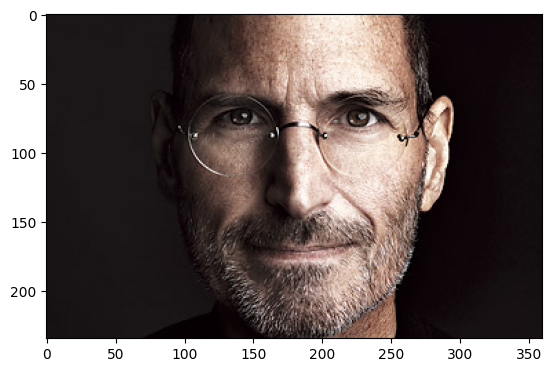

In [4]:
image=cv2.imread('steve.jpg')
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [5]:
image.shape

(235, 360, 3)

In [6]:
image.ndim

3

In [14]:
for_seg = image.reshape(-1,3) # 235*360,3
for_seg_float = np.float32(for_seg) # mandatory step to use the pixel values in cv2 kmeans

array([[28., 24., 25.],
       [28., 24., 25.],
       [28., 24., 25.],
       ...,
       [23., 17., 19.],
       [23., 17., 19.],
       [23., 17., 19.]], shape=(84600, 3), dtype=float32)

In [33]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,100,0.85)
compact,labels,centroids = cv2.kmeans(for_seg_float,3,criteria,None,10,cv2.KMEANS_PP_CENTERS) #init='kmeans++'

In [34]:
centroids = np.uint8(centroids)
centroids

array([[ 25,  18,  19],
       [224, 199, 185],
       [132, 103,  92]], dtype=uint8)

In [35]:
labels

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(84600, 1), dtype=int32)

In [36]:
mapped_pixel_with_labels = centroids[labels.flatten()] #
mapped_pixel_with_labels

array([[25, 18, 19],
       [25, 18, 19],
       [25, 18, 19],
       ...,
       [25, 18, 19],
       [25, 18, 19],
       [25, 18, 19]], shape=(84600, 3), dtype=uint8)

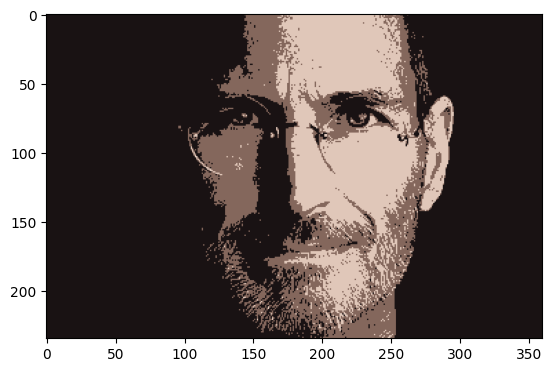

In [37]:
segmented_image = mapped_pixel_with_labels.reshape(image.shape)
plt.imshow(segmented_image)

In [39]:
from sklearn.cluster import KMeans

In [49]:
kmeans = KMeans(n_clusters=4,init='k-means++')
kmeans.fit(for_seg_float)
kmeans.inertia_

49284600.0

In [52]:
inertia=[]
for cluster in range(2,10):
    kmeans = KMeans(n_clusters=cluster,init='k-means++')
    kmeans.fit(for_seg_float)
    print(f"clusters {cluster} : Inertia {kmeans.inertia_}")
    inertia.append(kmeans.inertia_)
inertia

clusters 2 : Inertia 207732032.0
clusters 3 : Inertia 82419544.0
clusters 4 : Inertia 49267740.0
clusters 5 : Inertia 38779280.0
clusters 6 : Inertia 25659080.0
clusters 7 : Inertia 19048548.0
clusters 8 : Inertia 14939900.0
clusters 9 : Inertia 12149060.0


[207732032.0,
 82419544.0,
 49267740.0,
 38779280.0,
 25659080.0,
 19048548.0,
 14939900.0,
 12149060.0]

In [53]:
frame = pd.DataFrame({'Cluster':range(2,10),'inertia':inertia})
frame

,Cluster,inertia
0,2,207732032.0
1,3,82419544.0
2,4,49267740.0
3,5,38779280.0
4,6,25659080.0
5,7,19048548.0
6,8,14939900.0
7,9,12149060.0


In [ ]:
plt.figure(figsize=(8,4))
plt.plot(frame['Cluster'],frame['inertia'],marker='o')
plt.xlabel('No of Clusters')
plt.ylabel('No of Clusters')